# Simulação Numérica de Lançamento Vertical
Este notebook apresenta o modelo físico e a implementação em Python de um lançamento vertical com resistência do ar quadrática usando o método de integração numérica de Euler.

## 1. Modelo Físico
A segunda lei de Newton estabelece que:
$$F_{resultante} = m \cdot a$$

As forças que atuam no corpo são a força gravítica ($F_g$) e a força de resistência do ar ($F_{ar}$):
$$F_g = -m \cdot g$$
$$F_{ar} = -k \cdot v \cdot |v|$$

Logo, a aceleração num instante $t$ é:
$$a(t) = -g - \frac{k}{m} \cdot v(t) \cdot |v(t)|$$

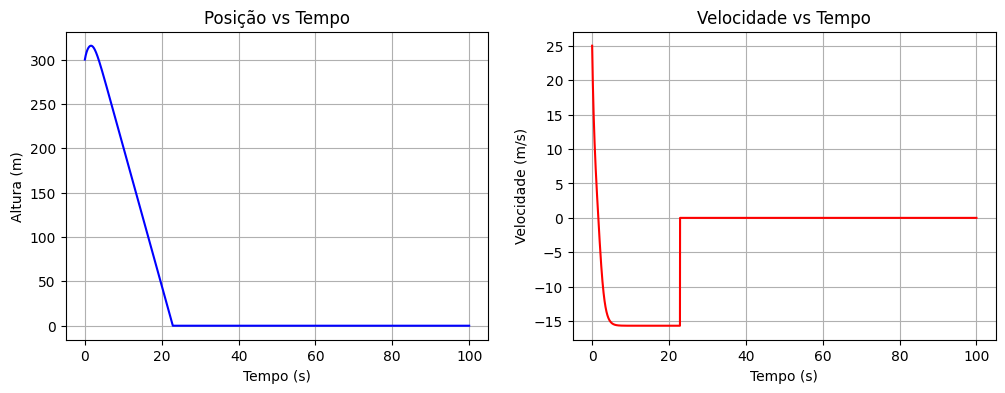

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def simular_lancamento(y0, v0, m, g, k, dt=0.01):
    t = 0
    y = y0
    v = v0
    
    tempos = [t]
    posicoes = [y]
    velocidades = [v]
    
    while y >= 0:
        f_ar = -k * v * abs(v)
        f_g = -m * g
        a = (f_g + f_ar) / m
        
        v += a * dt
        y += v * dt
        t += dt
        
        if y < 0:
            y = 0
            v = 0
        
        tempos.append(t)
        posicoes.append(y)
        velocidades.append(v)
        
        if len(tempos) > 10000: # Salvaguarda
            break
            
    return np.array(tempos), np.array(posicoes), np.array(velocidades)

# Exemplo de execução (Terra, Massa 1kg, v0=25m/s, y0=300m, k=0.04)
t, y, v = simular_lancamento(y0=300, v0=25, m=1.0, g=9.81, k=0.04)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t, y, color='blue')
ax1.set_title('Posição vs Tempo')
ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('Altura (m)')
ax1.grid(True)

ax2.plot(t, v, color='red')
ax2.set_title('Velocidade vs Tempo')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Velocidade (m/s)')
ax2.grid(True)
plt.show()

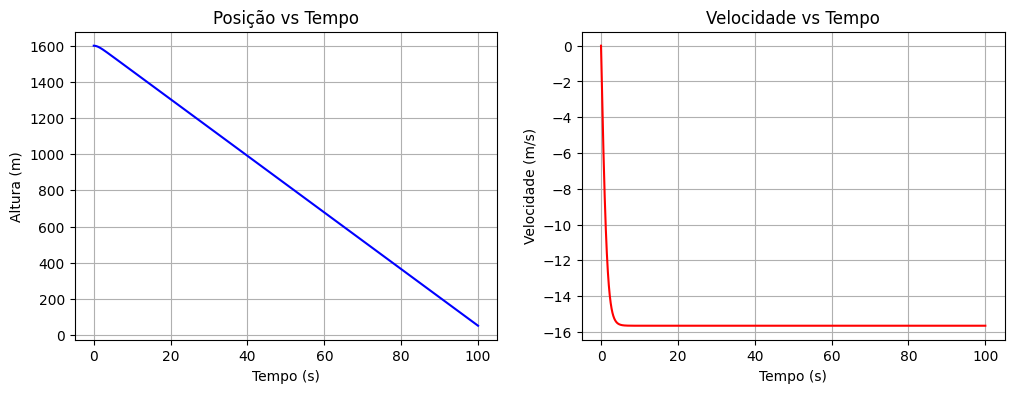

In [8]:
t, y, v = simular_lancamento(y0=1600, v0=0, m=1.0, g=9.81, k=0.04)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t, y, color='blue')
ax1.set_title('Posição vs Tempo')
ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('Altura (m)')
ax1.grid(True)

ax2.plot(t, v, color='red')
ax2.set_title('Velocidade vs Tempo')
ax2.set_xlabel('Tempo (s)')
ax2.set_ylabel('Velocidade (m/s)')
ax2.grid(True)
plt.show()